# Assignment 2 : Choose Your Own Analysis
### Research Question:
### Who holds greater authority in online health discussions on YouTube, licensed medical professionals or wellness influencers?
### Group Number : PG Group 18
### Members:
### Akash - s4137826
### Asmi Faisel - s4134240
### Sreelakshmi Thalodil Sunilkumar- s4146925



## 1. Data Collection

In [1]:

# Data handling
import pandas as pd   # Used for reading, storing, cleaning, and analysing data in table format, such as rows and columns.
import numpy as np    # Used for numerical operations, particularly when dealing with calculations, arrays, and missing data.
import json           # Used to read and process JSON data, a popular format for information gathered from YouTube and other APIs.
import os             # Used to check the saved CSV file size in bytes

# Text processing 
import re              # Used to remove links, numerals, and special characters from text using patterns.
import string          # Makes punctuation symbols accessible, which aids in removing punctuation from text.

#  NLP 
import nltk           # Natural Language Toolkit, used for basic text analysis tasks.

# Used to eliminate words that don't add much meaning, such as "the," "is," and "and."
from nltk.corpus import stopwords 

# Used to determine if a comment is neutral, negative, or favorable.
from nltk.sentiment import SentimentIntensityAnalyzer

# Before utilizing the necessary NLTK resources, download them once.

# Downloads the list of frequently used stopwords required for text cleaning.
nltk.download('stopwords')

# Downloads the VADER sentiment dictionary used for sentiment analysis.
nltk.download('vader_lexicon')

#  Tokenization 

# Used to determine how frequently users, words, or themes appear in the dataset.
from collections import Counter

# Topic modelling 

# Counts the frequency of words in cleaned text to translate it into numbers that machine learning algorithms can comprehend.
from sklearn.feature_extraction.text import CountVectorizer

# Used for topic modeling, which aids in identifying topics or hidden themes in the comments.
from sklearn.decomposition import LatentDirichletAllocation

# Network analysis 
# Used to build and examine networks, including connections between users, channels, and comments.
import networkx as nx

# Visualisation 

# Used to make simple charts and graphs to graphically illustrate the analysis.
import matplotlib.pyplot as plt

# Used to make statistical visualisations look cleaner and easier to understand.
import seaborn as sns

# wordcloud

# Used to produce a word cloud that visually displays the most common terms.
from wordcloud import WordCloud
# Import Patch to create custom legend entries for network visualisation
from matplotlib.patches import Patch
# Import Louvain community detection algorithm
# This is used to identify clusters (communities) of users in the network
import community as community_louvain

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sreelakshmi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/sreelakshmi/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
#Tokenization and text preparation

#TweetTokenizer is particularly helpful for social media content since it handles emojis, hashtags, short forms, and informal language better. 
#Tokenization is used to divide text into smaller sections called tokens (words).

from nltk.tokenize import TweetTokenizer

#Common stopwords like "the," "is," and "and" that are typically 
#eliminated during text cleaning since they don't provide significant information are imported.
from nltk.corpus import stopwords

# Used to determine how frequently words, hashtags, or other objects appear in the dataset.
from collections import Counter

# Before utilizing the necessary NLTK resources, download them just once.

# Downloads the stopword dataset needed to exclude frequently occurring words.
nltk.download('stopwords')

# Downloads the Punkt tokenizer models needed for sentence and word tokenization.
nltk.download('punkt')

# Downloads additional Punkt tokenizer tables required in some newer NLTK versions.
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sreelakshmi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/sreelakshmi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/sreelakshmi/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

#### The YouTube Data API was used to collect the dataset. The API key and execution call have been removed from the submitted code for security reasons.

### 2.1 Loading Dataset

In [6]:
# Open the original doctor/mental health dataset. 
# The initial collection of YouTube videos and comments is already included in this file.
with open("mental_health_dataset.json", "r", encoding="utf-8") as f:
    data1 = json.load(f)

# Open the updated influencer dataset.
# The extra videos and comments gathered independently are included in this file.
with open("influencer_dataset.json", "r", encoding="utf-8") as f:
    data2 = json.load(f)

# Gather every video ID from the original dataset. 
# Since videoId uniquely identifies every YouTube video, we use it.
existing_ids = {v["videoId"] for v in data1["videos"]}

#In order to avoid counting the same video and its comments again, only the influencer videos that weren't already in the 
#original dataset should be kept.
new_videos   = [v for v in data2["videos"] if v["videoId"] not in existing_ids]

# Merge the new, non-duplicate videos with the original ones.
# Only new influencer videos are included to the final dataset, which retains all original videos.
combined = {"videos": data1["videos"] + new_videos}

# Save the combined dataset back into the primary mental health dataset file. 
# This adds content about doctors and influencers to the file.
with open("mental_health_dataset.json", "w", encoding="utf-8") as f:
    json.dump(combined, f, ensure_ascii=False, indent=2)

print("=====================================")
print(" Merged!")
print(f"Original videos  : {len(data1['videos'])}")
print(f"New videos added : {len(new_videos)}")
print(f"Total videos     : {len(combined['videos'])}")
print(f"Total comments   : {sum(len(v['comments']) for v in combined['videos'])}")
print("=====================================")

 Merged!
Original videos  : 60
New videos added : 29
Total videos     : 89
Total comments   : 19340


In [7]:
# To store all comment-level data, create an empty list.
# Each comment will eventually be a single row in the final DataFrame.
all_rows = []

# Iterate over every video in the merged dataset.
for video in combined["videos"]:
    # Loop through every comment inside the current video.
    for comment in video["comments"]:
        # Store both video information and comment information together.
        # This creates a structured row that is easier to analyse later.
        all_rows.append({
            "video_id":      video["videoId"],     # Unique ID of the YouTube video.
            "title":         video["title"],       # Title of the video where the comment was posted.
            "channel":       video["channelTitle"],  # Name of the YouTube channel that uploaded the video.
            "view_count":    video["viewCount"],     # Total number of views for the video.
            "like_count":    video["likeCount"],     # Total number of likes for the video.
            "comment":       comment["text"],        # Actual text content of the YouTube comment.
            "author":        comment["author"],      # Username of the person who posted the comment.
            "reply_to":      comment["reply_to"],    # Shows who the comment was replying to.
                                                     # If it is a main comment, this value will be None.
            "comment_likes": comment["likeCount"],   # Number of likes received by the comment itself.
            "published_at":  comment["publishedAt"]  # Date and time when the comment was posted.
        })


# Convert the list of dictionaries into a Pandas DataFrame.
# A DataFrame makes the dataset easier to clean, analyse, and visualise.
df = pd.DataFrame(all_rows)

# Print a confirmation message to show the DataFrame was created successfully.
print(f" DataFrame rebuilt!")

# Print the total number of comments collected in the dataset.
print(f"Total comments: {len(df)}")


 DataFrame rebuilt!
Total comments: 19340


In [8]:
# opening the saved dataset file in read mode
with open("mental_health_dataset.json", "r", encoding="utf-8") as f:
    # load the JSON data from the file into a Python dictionary
    data = json.load(f)
# extract the list of videos from the dataset
videos = data["videos"]
# print how many videos were collected
print("Total videos:", len(videos))

Total videos: 89


In [9]:
# create an empty list to store all comments from all videos
all_comments = []
# loop through each video in dataset.
for video in videos:
    # loop through each comment inside the current video
    for comment in video["comments"]:
        # extract the comment text and add it to the list.
        all_comments.append(comment["text"])
# print the total number of comments collected
print("Total comments:", len(all_comments))

Total comments: 19340


In [10]:
# create an empty list to store structured data
all_rows = []

# loop through each video in the dataset
for video in videos:
    # loop through each comment of the current video
    for comment in video["comments"]:
        all_rows.append({
            # video information
            "video_id":      video["videoId"],
            "title":         video["title"],
            "channel":       video["channelTitle"],  # for labelling
            "view_count":    video["viewCount"],
            "like_count":    video["likeCount"],

            # comment information
            "comment":       comment["text"],         # comment text
            "author":        comment["author"],        # for network nodes
            "reply_to":      comment["reply_to"],      # for network edges
            "comment_likes": comment["likeCount"],
            "published_at":  comment["publishedAt"]
        })

# convert to dataframe
df = pd.DataFrame(all_rows)

# print summary
print("Total comments:", len(df))
print("Columns:", df.columns.tolist())
df.head()

Total comments: 19340
Columns: ['video_id', 'title', 'channel', 'view_count', 'like_count', 'comment', 'author', 'reply_to', 'comment_likes', 'published_at']


,video_id,title,channel,view_count,like_count,comment,author,reply_to,comment_likes,published_at
0,ep8ZMq3GLNA,Doctor Fact-Checks TikTok Nutrition Advice,Doctor Mike,14268953,293905,Y'know what makes a surprisingly great comfort...,@timdaferretmailman7297,None,1,2026-05-20T22:42:46Z
1,ep8ZMq3GLNA,Doctor Fact-Checks TikTok Nutrition Advice,Doctor Mike,14268953,293905,4:07 this is witchcraft. this is my thing 😭 TH...,@TheZootedPriestess,None,0,2026-05-18T23:13:59Z
2,ep8ZMq3GLNA,Doctor Fact-Checks TikTok Nutrition Advice,Doctor Mike,14268953,293905,I used to love me some codeine in my cough syr...,@robertvargas2324,None,0,2026-05-16T08:50:09Z
3,ep8ZMq3GLNA,Doctor Fact-Checks TikTok Nutrition Advice,Doctor Mike,14268953,293905,1:35 why would we want evidence from where you...,@elijahpolakoffTV,None,1,2026-05-11T22:18:02Z
4,ep8ZMq3GLNA,Doctor Fact-Checks TikTok Nutrition Advice,Doctor Mike,14268953,293905,Stop at a random moment 1:56,@BLUEBERRY33-c2j,None,0,2026-05-10T03:26:53Z


### 2.2 Data Cleaning

In [11]:
def clean_comment(text):
    # convert text to lowercase for consistency
    text = str(text).lower()
    
    # remove any URLs present in the text
    text = re.sub(r"http\S+", "", text)
    
    # remove emojis and non english characters
    text = re.sub(r"[^\x00-\x7F]+", "", text)
    
    # step to ensure only standard text remains
    text = text.encode("ascii", "ignore").decode()
    
    # keep only letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # remove extra spaces and clean formatting
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [12]:
# check what columns you actually have
print(df.columns.tolist())
print(df.shape)
print(df.head(3))

['video_id', 'title', 'channel', 'view_count', 'like_count', 'comment', 'author', 'reply_to', 'comment_likes', 'published_at']
(19340, 10)
      video_id                                       title      channel  \
0  ep8ZMq3GLNA  Doctor Fact-Checks TikTok Nutrition Advice  Doctor Mike   
1  ep8ZMq3GLNA  Doctor Fact-Checks TikTok Nutrition Advice  Doctor Mike   
2  ep8ZMq3GLNA  Doctor Fact-Checks TikTok Nutrition Advice  Doctor Mike   

   view_count  like_count                                            comment  \
0    14268953      293905  Y'know what makes a surprisingly great comfort...   
1    14268953      293905  4:07 this is witchcraft. this is my thing 😭 TH...   
2    14268953      293905  I used to love me some codeine in my cough syr...   

                    author reply_to  comment_likes          published_at  
0  @timdaferretmailman7297     None              1  2026-05-20T22:42:46Z  
1      @TheZootedPriestess     None              0  2026-05-18T23:13:59Z  
2        @robe

In [13]:
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

video_id             0
title                0
channel              0
view_count           0
like_count           0
comment              0
author               0
reply_to         17139
comment_likes        0
published_at         0
dtype: int64


In [14]:
# apply cleaning function to all comments correct column name
df["clean_comment"] = df["comment"].apply(clean_comment)

# clean video titles as well correct column name
df["clean_title"] = df["title"].apply(clean_comment)

In [15]:
# store count before cleaning for comparison
before_count = len(df)

In [16]:
# remove empty comments
df = df[df["clean_comment"].str.strip() != ""]


In [17]:
# remove very short comments
df = df[df["clean_comment"].str.len() > 3]


In [18]:
# keep only comments that contain text
df = df[df["clean_comment"].str.contains(r"[a-zA-Z]", regex=True)]


In [19]:
# count non-english comments
non_english_count = df[~df["clean_comment"].apply(lambda x: str(x).isascii())].shape[0]
print("Non-English comments:", non_english_count)


Non-English comments: 0


In [20]:
# count english comments
english_count = df[df["clean_comment"].apply(lambda x: str(x).isascii())].shape[0]
print("English comments:", english_count)

English comments: 18825


In [21]:
duplicates = df.duplicated(subset=["clean_comment"]).sum()
print("Duplicate comments:", duplicates)

Duplicate comments: 344


In [22]:
# keep only english comments
df = df[df["clean_comment"].apply(lambda x: str(x).isascii())]

In [23]:
# remove duplicate comments
df = df.drop_duplicates(subset=["comment"])


In [24]:
# after count
after_count = len(df)


In [25]:
print("\n=====================================")
print("Cleaning Complete!")
print(f"Before cleaning : {before_count}")
print(f"After cleaning  : {after_count}")
print(f"Removed         : {before_count - after_count}")
print(f"English comments: {english_count}")
print(f"Non-English     : {non_english_count}")
print("=====================================")

# preview
df.head()


Cleaning Complete!
Before cleaning : 19340
After cleaning  : 18683
Removed         : 657
English comments: 18825
Non-English     : 0


,video_id,title,channel,view_count,like_count,comment,author,reply_to,comment_likes,published_at,clean_comment,clean_title
0,ep8ZMq3GLNA,Doctor Fact-Checks TikTok Nutrition Advice,Doctor Mike,14268953,293905,Y'know what makes a surprisingly great comfort...,@timdaferretmailman7297,None,1,2026-05-20T22:42:46Z,yknow what makes a surprisingly great comfort ...,doctor factchecks tiktok nutrition advice
1,ep8ZMq3GLNA,Doctor Fact-Checks TikTok Nutrition Advice,Doctor Mike,14268953,293905,4:07 this is witchcraft. this is my thing 😭 TH...,@TheZootedPriestess,None,0,2026-05-18T23:13:59Z,this is witchcraft this is my thing this is a ...,doctor factchecks tiktok nutrition advice
2,ep8ZMq3GLNA,Doctor Fact-Checks TikTok Nutrition Advice,Doctor Mike,14268953,293905,I used to love me some codeine in my cough syr...,@robertvargas2324,None,0,2026-05-16T08:50:09Z,i used to love me some codeine in my cough syr...,doctor factchecks tiktok nutrition advice
3,ep8ZMq3GLNA,Doctor Fact-Checks TikTok Nutrition Advice,Doctor Mike,14268953,293905,1:35 why would we want evidence from where you...,@elijahpolakoffTV,None,1,2026-05-11T22:18:02Z,why would we want evidence from where your mom...,doctor factchecks tiktok nutrition advice
4,ep8ZMq3GLNA,Doctor Fact-Checks TikTok Nutrition Advice,Doctor Mike,14268953,293905,Stop at a random moment 1:56,@BLUEBERRY33-c2j,None,0,2026-05-10T03:26:53Z,stop at a random moment,doctor factchecks tiktok nutrition advice


### 2.3 Labelling

 Labelling Complete!

Label Distribution (comments):
doctor        10472
influencer     4515
both           3696
Name: video_label, dtype: int64

 Label Distribution (unique videos):
video_label
both          18
doctor        50
influencer    21
Name: video_id, dtype: int64


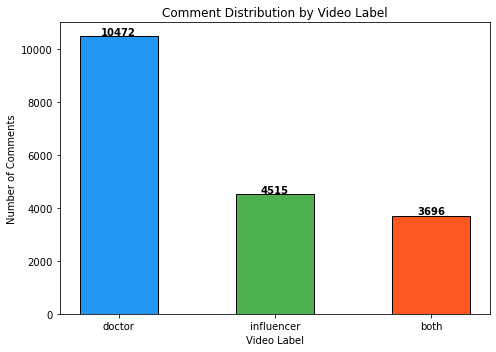


Saved with labels to mental_health_cleaned.csv

 Sample labelled data:
                                                  title  \
0            Doctor Fact-Checks TikTok Nutrition Advice   
208                 Doctor Blocks Me For Correcting Him   
419         Doctor Reacts To Scary TikTok Health Advice   
626   TikTok &quot;Health&quot; Products You Should ...   
847     Doctor Reacts To TERRIBLE TikTok Medical Advice   
1060                    The Truth About Detox Smoothies   
1264                      The Truth About Lemon Water 😲   
1471        How “Health Gurus” Trick You ft Gary Brecka   
1685      Debunking the worst haircare advice on TikTok   
1898  Here&#39;s Why Doctor&#39;s NEVER Drink Detox Tea   

                        channel video_label  
0                   Doctor Mike      doctor  
208                 Doctor Mike      doctor  
419                 Doctor Mike      doctor  
626                 Doctor Mike        both  
847                 Doctor Mike      doctor  
10

In [26]:

#  Define Keywords

# keywords that indicate medical professional / doctor content
DOCTOR_KEYWORDS = [
    'doctor', 'dr.', 'dr ', 'physician', 'surgeon', 'md ',
    'debunk', 'fact check', 'fact-check', 'medical', 'nurse',
    'gynecologist', 'urologist', 'scientist', 'cardiologist',
    'dermatologist', 'obgyn', 'psychiatrist', 'therapist',
    'biomedical', 'healthcare', 'debunking', 'reacts'
]

# keywords that indicate influencer / misinformation content
INFLUENCER_KEYWORDS = [
    'influencer', 'guru', 'coach', 'carnivore', 'wellness',
    'detox', 'natural cure', 'raw milk', 'supplement',
    'biohack', 'holistic', 'tiktok', 'instagram', 'viral',
    'exposed', 'conspiracy', 'alternative', 'naturopath',
    'hidden truth', 'they dont want', 'secret'
]


# Label Function

def label_video(title, channel):
    # combine title and channel for better accuracy
    text = (str(title) + " " + str(channel)).lower()

    doctor_score     = sum(1 for kw in DOCTOR_KEYWORDS     if kw in text)
    influencer_score = sum(1 for kw in INFLUENCER_KEYWORDS if kw in text)

    if doctor_score > influencer_score:
        return "doctor"
    elif influencer_score > doctor_score:
        return "influencer"
    else:
        return "both"


#  Apply Labels

df["video_label"] = df.apply(
    lambda row: label_video(row["title"], row["channel"]),
    axis=1
)


#  Print Distribution
print(" Labelling Complete!")
print("\nLabel Distribution (comments):")
print(df["video_label"].value_counts())
print("\n Label Distribution (unique videos):")
print(df.groupby("video_label")["video_id"].nunique())


# Visualise

# Count how many comments belong to each video category.
# value_counts() calculates the frequency of each label in the dataset.
label_counts = df["video_label"].value_counts()

# Create a new figure for the bar chart.
# figsize controls the size of the graph.
plt.figure(figsize=(7, 5))

# Create the bar chart.
# Each bar represents the number of comments for a specific video category.
bars = plt.bar(
    label_counts.index,
    label_counts.values,

    # Different colours are used to visually separate categories.
    color=["#2196F3", "#4CAF50", "#FF5722"],
    # Adds a black border around each bar for clarity.
    edgecolor="black",
    # Controls the width of each bar.
    width=0.5
)

# Add the exact count value on top of each bar.
# This makes the chart easier to read without estimating values visually.
for bar, count in zip(bars, label_counts.values):
    plt.text(
        # Places the text at the center of each bar.
        bar.get_x() + bar.get_width() / 2,
        # Places the text slightly above the top of the bar.
        bar.get_height() + 50,
        str(count),
        ha="center",
        fontweight="bold"
    )
# Add a title to explain what the graph shows.
plt.title("Comment Distribution by Video Label")
# Label the x-axis.
plt.xlabel("Video Label")
# Label the y-axis.
plt.ylabel("Number of Comments")
# Automatically adjusts spacing so labels do not overlap.
plt.tight_layout()
plt.show()


#  Save

df.to_csv("mental_health_cleaned.csv", index=False)
print("\nSaved with labels to mental_health_cleaned.csv")
print("\n Sample labelled data:")
print(df[["title", "channel", "video_label"]].drop_duplicates().head(10))

In [27]:
print(df.columns.tolist())

['video_id', 'title', 'channel', 'view_count', 'like_count', 'comment', 'author', 'reply_to', 'comment_likes', 'published_at', 'clean_comment', 'clean_title', 'video_label']


### 2.4 Tokenisation

In [28]:

class YouTubeProcessing:
    # create a class to handle text processing
    def __init__(self, tokeniser, lStopwords):
        # store the tokenizer
        self.tokeniser = tokeniser
        # store stopwords
        self.lStopwords = lStopwords

    # function to process and clean each piece of text
    def process(self, text):
        # convert text to lowercase for consistency
        text = text.lower()
        # split the text into individual words
        tokens = self.tokeniser.tokenize(text)
        # remove extra spaces around each token
        tokens = [tok.strip() for tok in tokens]
        # pattern to identify tokens containing numbers
        regexDigit = re.compile(r"^\d+\s|\s\d+\s|\s\d+$")
        # pattern to identify tokens starting with links
        regexHttp = re.compile(r"^http")
        return [tok for tok in tokens
                # remove common words like "the", "is" etc
                if tok not in self.lStopwords
                # remove tokens that contain numbers
                and regexDigit.match(tok) is None
                # remove tokens that are URLs
                and regexHttp.match(tok) is None]

In [29]:
# create tokeniser suitable for social media text
tokeniser = TweetTokenizer()

# combine english stopwords + punctuation + custom words
custom_stopwords = [
    "doctor", "doctors", "influencer", "influencers",
    "video", "youtube", "watch", "like", "comment",
    "said", "say", "says", "know", "think", "people",
    "one", "get", "got", "going", "would", "could",
    "really", "actually", "also", "even", "still",
    "tiktok", "instagram", "channel", "subscribe",
    "gt", "amp", "quot"                              # removes HTML artifacts
]

lStopwords = (
    stopwords.words('english') +
    list(string.punctuation) +
    custom_stopwords                                  # added for your project
)

# create processor object
processor = YouTubeProcessing(tokeniser, lStopwords)
print("Processor created")

Processor created


In [30]:
# apply processing function to each cleaned comment
df["tokens"] = df["clean_comment"].apply(lambda x: processor.process(str(x)))

# calculate token count per comment
df["token_count"] = df["tokens"].apply(len)

print("Tokenisation applied!")
print(f"Average tokens per comment: {df['token_count'].mean():.1f}")
print(f"Sample tokens: {df['tokens'].iloc[0]}")

Tokenisation applied!
Average tokens per comment: 13.5
Sample tokens: ['yknow', 'makes', 'surprisingly', 'great', 'comfort', 'bowl', 'imo', 'lettuce', 'fresh', 'tomatoes', 'refried', 'beans', 'melted', 'cheese', 'seasoned', 'rice', 'tried', 'mashed', 'together', 'almost', 'always', 'order', 'local', 'mexican', 'restaurant', 'lol']


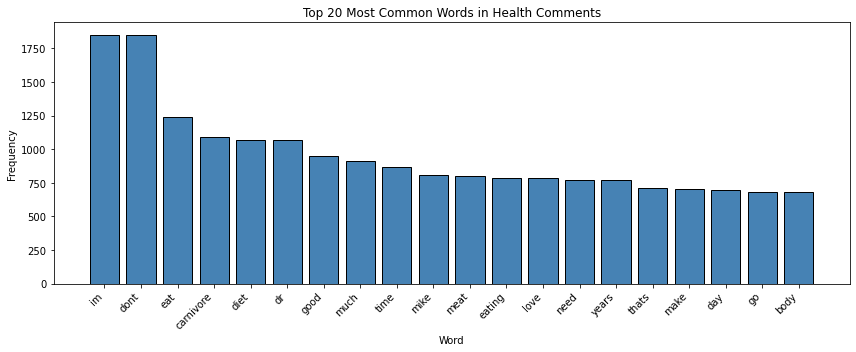

In [31]:
# flatten all tokens into one list
all_tokens = [
    token
    for tokens in df["tokens"]
    for token in tokens
]

# get top 20 words
most_common = Counter(all_tokens).most_common(20)
words  = [w[0] for w in most_common]
counts = [w[1] for w in most_common]

# plot
plt.figure(figsize=(12, 5))
plt.bar(words, counts, color="steelblue", edgecolor="black")
plt.title("Top 20 Most Common Words in Health Comments")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [32]:
# Loop through each video category separately.
# This allows us to compare the most common words used in different types of videos.
for label in ["doctor", "influencer", "both"]:
    # Create a list of all tokens belonging to the current label.
    # tokens = cleaned words from each comment
    # lbl = the category assigned to that comment/video
    label_tokens = [
        # Take each individual token (word)
        token
        # Loop through the tokenised comments and their labels together.
        for tokens, lbl in zip(df["tokens"], df["video_label"])
        # Keep only comments that belong to the current label.
        if lbl == label
        # Loop through every word inside each token list.
        for token in tokens
    ]
    print(f"\n Top 10 words in '{label}' videos:")
    print(Counter(label_tokens).most_common(10))


 Top 10 words in 'doctor' videos:
[('dont', 978), ('im', 960), ('dr', 699), ('mike', 678), ('time', 501), ('much', 441), ('water', 440), ('good', 424), ('love', 409), ('thats', 394)]

 Top 10 words in 'influencer' videos:
[('eat', 741), ('carnivore', 626), ('diet', 587), ('dont', 560), ('im', 552), ('meat', 528), ('eating', 440), ('milk', 336), ('good', 329), ('food', 328)]

 Top 10 words in 'both' videos:
[('de', 550), ('e', 455), ('que', 438), ('im', 338), ('dont', 308), ('diet', 286), ('carnivore', 230), ('dr', 203), ('good', 196), ('eat', 181)]


In [33]:
# Save the cleaned DataFrame as a CSV file.
# index=False prevents Pandas from adding an extra row-number column to the file.
df.to_csv("mental_health_cleaned.csv", index=False)
# Print a confirmation message to show the file was saved successfully.
print("\nSaved with tokens to mental_health_cleaned.csv")

# Display the first 5 rows of the DataFrame.
# This helps quickly inspect whether the cleaned dataset looks correct.
df.head()


Saved with tokens to mental_health_cleaned.csv


,video_id,title,channel,view_count,like_count,comment,author,reply_to,comment_likes,published_at,clean_comment,clean_title,video_label,tokens,token_count
0,ep8ZMq3GLNA,Doctor Fact-Checks TikTok Nutrition Advice,Doctor Mike,14268953,293905,Y'know what makes a surprisingly great comfort...,@timdaferretmailman7297,None,1,2026-05-20T22:42:46Z,yknow what makes a surprisingly great comfort ...,doctor factchecks tiktok nutrition advice,doctor,"[yknow, makes, surprisingly, great, comfort, b...",26
1,ep8ZMq3GLNA,Doctor Fact-Checks TikTok Nutrition Advice,Doctor Mike,14268953,293905,4:07 this is witchcraft. this is my thing 😭 TH...,@TheZootedPriestess,None,0,2026-05-18T23:13:59Z,this is witchcraft this is my thing this is a ...,doctor factchecks tiktok nutrition advice,doctor,"[witchcraft, thing, spell, medical, stuff]",5
2,ep8ZMq3GLNA,Doctor Fact-Checks TikTok Nutrition Advice,Doctor Mike,14268953,293905,I used to love me some codeine in my cough syr...,@robertvargas2324,None,0,2026-05-16T08:50:09Z,i used to love me some codeine in my cough syr...,doctor factchecks tiktok nutrition advice,doctor,"[used, love, codeine, cough, syrup, especially...",8
3,ep8ZMq3GLNA,Doctor Fact-Checks TikTok Nutrition Advice,Doctor Mike,14268953,293905,1:35 why would we want evidence from where you...,@elijahpolakoffTV,None,1,2026-05-11T22:18:02Z,why would we want evidence from where your mom...,doctor factchecks tiktok nutrition advice,doctor,"[want, evidence, mom, died]",4
4,ep8ZMq3GLNA,Doctor Fact-Checks TikTok Nutrition Advice,Doctor Mike,14268953,293905,Stop at a random moment 1:56,@BLUEBERRY33-c2j,None,0,2026-05-10T03:26:53Z,stop at a random moment,doctor factchecks tiktok nutrition advice,doctor,"[stop, random, moment]",3


### 2.5 Intial Exploration (EDA)

In [34]:
# Group the dataset by video ID.
# size() counts how many comments belong to each video.
comments_per_video = df.groupby("video_id").size()

# Display summary statistics for the number of comments per video.
# describe() provides useful information such as:
# - count  → total number of videos
# - mean   → average comments per video
# - std    → variation in comment counts
# - min    → lowest number of comments
# - max    → highest number of comments
# - quartiles (25%, 50%, 75%) → distribution of comment activity
print(comments_per_video.describe())

count     89.000000
mean     209.921348
std       27.867472
min       99.000000
25%      201.000000
50%      210.000000
75%      220.000000
max      291.000000
dtype: float64


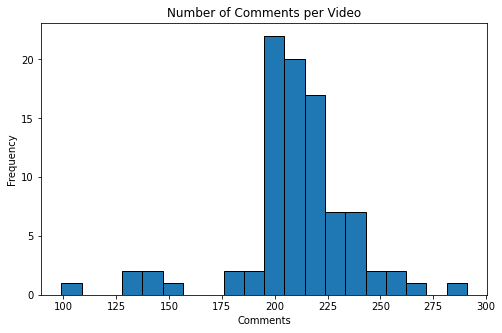

In [35]:
# Create a new figure for the histogram.
# figsize controls the width and height of the graph.
plt.figure(figsize=(8,5))

# Create a histogram to show the distribution of comment counts across videos.
# Each bar represents how many videos fall within a certain comment range
plt.hist(comments_per_video, bins=20, edgecolor="black")
plt.title("Number of Comments per Video")
plt.xlabel("Comments")
plt.ylabel("Frequency")
plt.show()

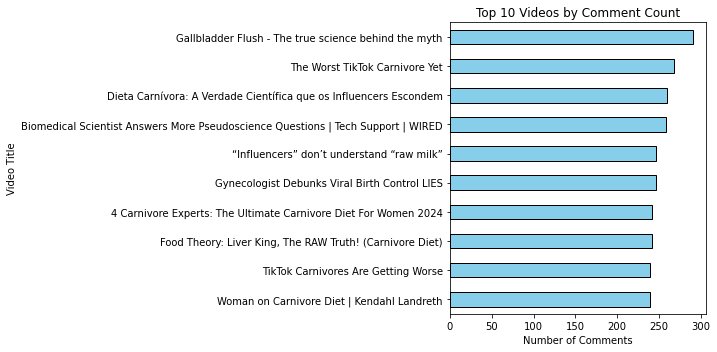

In [36]:
# Sort videos based on the number of comments in descending order.
# head(10) selects the top 10 most commented videos.
top_videos = comments_per_video.sort_values(ascending=False).head(10)

# Replace video IDs with actual video titles for better readability in the graph.
# groupby("video_id")["title"].first() gets the title linked to each video ID.
top_videos.index = df.groupby("video_id")["title"].first().loc[top_videos.index]

# Create a horizontal bar chart.
# Each bar represents one of the top 10 most commented videos.
plt.figure(figsize=(10,5))
top_videos.plot(kind="barh", color="skyblue", edgecolor="black")
plt.gca().invert_yaxis()
plt.title("Top 10 Videos by Comment Count")
plt.xlabel("Number of Comments")
plt.ylabel("Video Title")
plt.tight_layout()
plt.show()

## 3. Text Analysis

### 3.1 Unigram Analysis

In [37]:
# Create an empty dictionary to store unigram results for each video category.
# A unigram means a single word.
unigram_results = {}

# Loop through each video label separately.
# This helps compare the language used across different categories.
for label in ["doctor", "influencer", "both"]:

    # Create an empty list to store all words for the current category.
    all_words = []

    # Loop through tokenised comments and their corresponding labels together.
    for tokens, lbl in zip(df["tokens"], df["video_label"]):
        # Keep only comments that belong to the current label.
        if lbl == label:
            # Add all words from the current comment into the list.
            all_words.extend(tokens)

    # Count how often each word appears in the selected category.
    word_freq = Counter(all_words)

    # Select the 10 most common words.
    top_words = word_freq.most_common(10)

    # Store the results in the dictionary for later use or analysis.
    unigram_results[label] = top_words
    
    print(f"\nTop words in {label} videos:")
    print(top_words)


Top words in doctor videos:
[('dont', 978), ('im', 960), ('dr', 699), ('mike', 678), ('time', 501), ('much', 441), ('water', 440), ('good', 424), ('love', 409), ('thats', 394)]

Top words in influencer videos:
[('eat', 741), ('carnivore', 626), ('diet', 587), ('dont', 560), ('im', 552), ('meat', 528), ('eating', 440), ('milk', 336), ('good', 329), ('food', 328)]

Top words in both videos:
[('de', 550), ('e', 455), ('que', 438), ('im', 338), ('dont', 308), ('diet', 286), ('carnivore', 230), ('dr', 203), ('good', 196), ('eat', 181)]


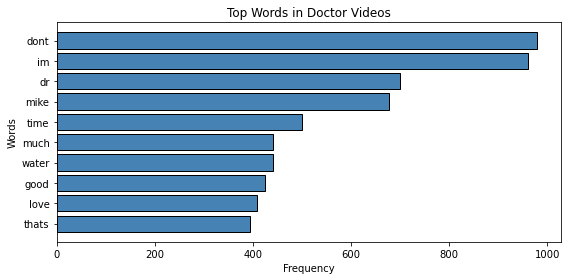

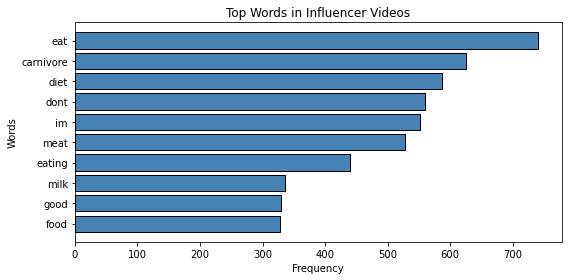

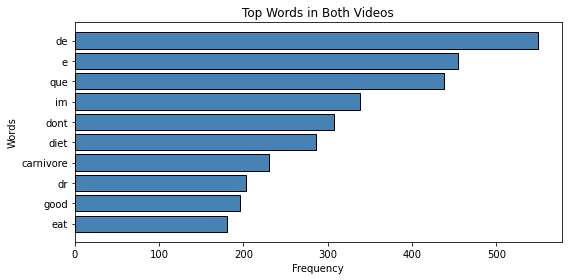

In [38]:
# Visualise the most common words for each video category.
# This helps compare the language and discussion themes across different types of videos.

# Loop through each category and its top words.
for label, top_words in unigram_results.items():

    # Separate words and their frequencies into two lists.
    words = [w for w, c in top_words]
    counts = [c for w, c in top_words]

    # Reverse the lists so the highest frequency appears at the top of the chart.
    words.reverse()
    counts.reverse()

    # Create a new figure for the horizontal bar chart.
    plt.figure(figsize=(8,4))

    # Create the horizontal bar chart.
    # Each bar represents the frequency of a word in the selected category.
    plt.barh(words, counts, color="steelblue", edgecolor="black")
    
    plt.title(f"Top Words in {label.capitalize()} Videos")
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    
    plt.tight_layout()
    plt.show()

### 3.2 Bigram Analysis

In [39]:

# Create an empty dictionary to store bigram results for each category.
# A bigram is a pair of consecutive words that appear together.
bigram_results = {}

# Loop through each video category separately.
# This helps compare common word pairs across different types of videos.
for label in ["doctor", "influencer", "both"]:

    # Create an empty list to store all bigrams for the current category.
    bigrams = []

    # Loop through tokenised comments and their corresponding labels together.
    for tokens, lbl in zip(df["tokens"], df["video_label"]):
        # Keep only comments that belong to the current label.
        if lbl == label:
            # Loop through the token list and create pairs of consecutive words.
            for i in range(len(tokens) - 1):
                # Store each pair of words as a tuple.
                bigrams.append((tokens[i], tokens[i+1]))

    # Count how often each bigram appears.
    bigram_freq = Counter(bigrams)

    # Select the 10 most common bigrams.
    top_bigrams = bigram_freq.most_common(10)

    # Store the results for later analysis or visualisation.
    bigram_results[label] = top_bigrams
    
    print(f"\nTop bigrams in {label} videos:")
    print(top_bigrams)


Top bigrams in doctor videos:
[(('dr', 'mike'), 320), (('birth', 'control'), 135), (('please', 'please'), 70), (('years', 'ago'), 64), (('every', 'time'), 52), (('lemon', 'water'), 45), (('dont', 'need'), 44), (('olive', 'oil'), 43), (('carnivore', 'diet'), 43), (('chest', 'compressions'), 40)]

Top bigrams in influencer videos:
[(('carnivore', 'diet'), 177), (('raw', 'milk'), 169), (('red', 'meat'), 67), (('dont', 'eat'), 53), (('eat', 'meat'), 45), (('every', 'day'), 41), (('years', 'ago'), 40), (('lose', 'weight'), 37), (('social', 'media'), 33), (('dr', 'berg'), 31)]

Top bigrams in both videos:
[(('dr', 'mike'), 73), (('carnivore', 'diet'), 70), (('tongkat', 'ali'), 42), (('dieta', 'carnvora'), 40), (('snake', 'oil'), 30), (('detox', 'tea'), 28), (('big', 'pharma'), 27), (('god', 'bless'), 23), (('every', 'day'), 20), (('blood', 'pressure'), 20)]


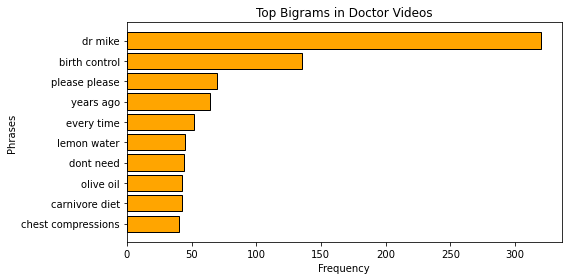

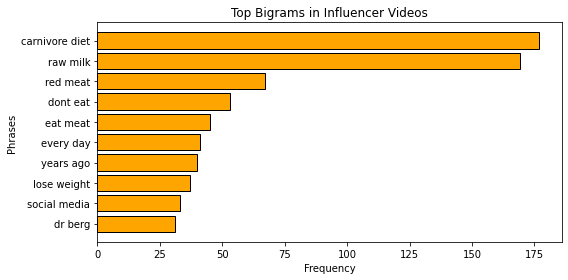

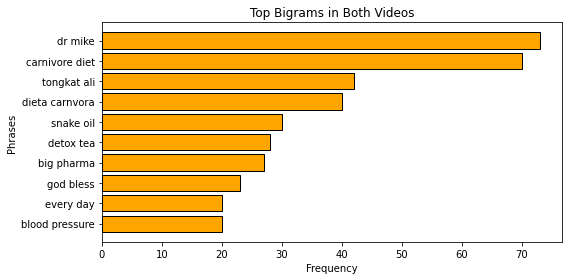

In [40]:
# Visualise the most common bigrams for each video category.
# This helps identify common word pair patterns and discussion themes.

# Loop through each category and its top bigrams.
for label, top_bigrams in bigram_results.items():

    # Combine each word pair into a readable phrase.
    # Example: ("mental", "health") → "mental health"
    phrases = [f"{w1} {w2}" for (w1, w2), c in top_bigrams]
    # Extract the frequency count for each bigram.
    counts = [c for (w1, w2), c in top_bigrams]

    # Reverse the lists so the most frequent phrase appears at the top.
    phrases.reverse()
    counts.reverse()

    # Create a new figure for the chart.
    plt.figure(figsize=(8,4))

    # Create a horizontal bar chart.
    # Each bar represents how often a phrase appears.
    plt.barh(phrases, counts, color="orange", edgecolor="black")
    
    plt.title(f"Top Bigrams in {label.capitalize()} Videos")
    plt.xlabel("Frequency")
    plt.ylabel("Phrases")
    
    plt.tight_layout()
    plt.show()

### 3.3 Sentiment Analysis

In [41]:
# download once
nltk.download('vader_lexicon')

# Create an instance of the sentiment analyser.
# This object will later calculate sentiment scores for each comment.
sia = SentimentIntensityAnalyzer()

# Calculate sentiment scores for each cleaned comment.
# polarity_scores() returns multiple sentiment values:
# - positive
# - negative
# - neutral
# - compound
#
# We use the compound score because it gives an overall sentiment score
# ranging from -1 (very negative) to +1 (very positive).
df["sentiment_score"] = df["clean_comment"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

# Create a function to convert numerical sentiment scores into labels.
# This makes the results easier to interpret.
def get_sentiment_label(score):

    # Positive score means the comment expresses positive sentiment.
    if score > 0:
        return "positive"

    # Negative score means the comment expresses negative sentiment
    elif score < 0:
        return "negative"

    # A score of 0 is treated as neutral sentiment.
    else:
        return "neutral"

df["sentiment"] = df["sentiment_score"].apply(get_sentiment_label)

print(df[["clean_comment", "sentiment_score", "sentiment"]].head())

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/sreelakshmi/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                       clean_comment  sentiment_score  \
0  yknow what makes a surprisingly great comfort ...           0.9169   
1  this is witchcraft this is my thing this is a ...           0.0000   
2  i used to love me some codeine in my cough syr...           0.8428   
3  why would we want evidence from where your mom...          -0.5106   
4                            stop at a random moment          -0.2960   

  sentiment  
0  positive  
1   neutral  
2  positive  
3  negative  
4  negative  


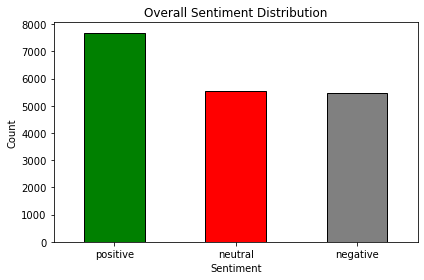

positive    7684
neutral     5535
negative    5464
Name: sentiment, dtype: int64


In [42]:
# Count how many comments belong to each sentiment category.
# value_counts() calculates the frequency of positive, negative, and neutral comments.
sentiment_counts = df["sentiment"].value_counts()

# Create a new figure for the bar chart.
# figsize controls the width and height of the graph.
plt.figure(figsize=(6,4))

# Create a bar chart to visualise the sentiment distribution.
# Each bar represents the number of comments in a sentiment category.
sentiment_counts.plot(kind="bar", color=["green", "red", "gray"], edgecolor="black")

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(sentiment_counts)

In [43]:
# Group the dataset by video category.
# Then calculate the average sentiment score for each category.
# mean() helps measure the overall emotional tone of comments in each group.
sentiment_by_label = df.groupby("video_label")["sentiment_score"].mean()

# Display the average sentiment score for each video category.
# Higher positive values indicate more positive audience reactions,
# while lower negative values indicate more negative sentiment.
print("\nAverage Sentiment Score by Label:")
print(sentiment_by_label)


Average Sentiment Score by Label:
video_label
both          0.098809
doctor        0.067800
influencer    0.075680
Name: sentiment_score, dtype: float64


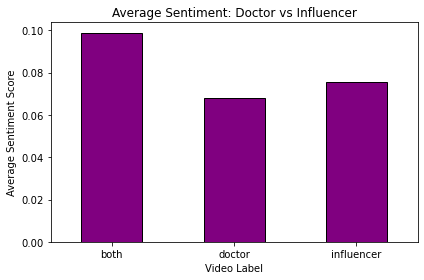

In [44]:
# Create a bar chart to compare the average sentiment score
# across different video categories.
sentiment_by_label.plot(kind="bar", color="purple", edgecolor="black")

# Add a title describing the purpose of the graph.
# This chart compares audience sentiment between doctor and influencer videos.
plt.title("Average Sentiment: Doctor vs Influencer")
plt.xlabel("Video Label")
plt.ylabel("Average Sentiment Score")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.4 Topic Analysis

In [45]:
from sklearn.feature_extraction.text import CountVectorizer

# Create a CountVectorizer object.
# This will prepare the text data for topic modelling and machine learning.
vectorizer = CountVectorizer(
    # Ignores words that appear in more than 90% of comments.
    # These words are usually too common to provide meaningful insights.
    max_df=0.9,

    # Keeps only words that appear at least 10 times in the dataset.
    # This removes very rare words that may add noise.
    min_df=10,

    # Automatically removes common English stopwords
    # such as "the", "is", and "and".
    stop_words='english'
)

# Convert the cleaned comments into a document-term matrix.
# Rows represent comments.
# Columns represent words.
# Values represent how often each word appears in each comment.
X = vectorizer.fit_transform(df["clean_comment"])

In [46]:
from sklearn.decomposition import LatentDirichletAllocation

# Create the LDA model.
lda = LatentDirichletAllocation(

    # Defines the number of topics the model should discover.
    # Here, the model will group comments into 5 different topics.
    n_components=5,   # number of topics

    # Sets a fixed random seed so results remain consistent each time the code runs.
    random_state=42
)

# Train the LDA model using the document-term matrix created earlier.
# The model analyses word patterns and learns which words frequently appear together.
lda.fit(X)

LatentDirichletAllocation(n_components=5, random_state=42)

In [47]:
# Get all feature names (words) learned by the CountVectorizer.
# These are the words used by the LDA model during topic modelling.
words = vectorizer.get_feature_names()

# Loop through each discovered topic.
# enumerate() gives:
# - i      → topic number
# - topic  → importance scores of words within that topic
for i, topic in enumerate(lda.components_):
    # topic.argsort() sorts words based on their importance scores.
    # [-10:] selects the 10 most important words for the topic.
    # The list comprehension converts word indexes into actual words.
    print(f"\nTopic {i}:")
    print([words[i] for i in topic.argsort()[-10:]])


Topic 0:
['food', 'dont', 'water', 'just', 'like', 'eating', 'meat', 'carnivore', 'diet', 'eat']

Topic 1:
['watching', 'thanks', 'god', 'videos', 'great', 'hair', 'thank', 'im', 'love', 'video']

Topic 2:
['com', 'youtube', 'um', 'doc', 'house', 'bro', 'que', 'doctor', 'mike', 'dr']

Topic 3:
['medical', 'health', 'make', 'know', 'think', 'im', 'dont', 'just', 'people', 'like']

Topic 4:
['went', 'didnt', 'pain', 'like', 'just', 'time', 'im', 'got', 'years', 'did']


In [48]:
# Loop through each video category separately.
# This allows topic modelling to be performed independently
# for doctor videos and influencer videos.
for label in ["doctor", "influencer"]:

    # Create a subset of the dataset containing only the selected category.
    subset = df[df["video_label"] == label]

    # Create a CountVectorizer object to convert text into numerical form.
    vectorizer = CountVectorizer(max_df=0.9, min_df=10, stop_words='english')

    # Convert cleaned comments into a document-term matrix.
    # This matrix is required for topic modelling.
    X = vectorizer.fit_transform(subset["clean_comment"])

    # Create the LDA topic modelling algorithm.
    lda = LatentDirichletAllocation(n_components=3, random_state=42)
    # Train the LDA model on the current category's comments.
    lda.fit(X)

    # Get the list of words learned by the vectorizer.
    words = vectorizer.get_feature_names()
    
    print(f"\nTopics in {label} videos:")

    # Loop through each discovered topic.
    for i, topic in enumerate(lda.components_):
        print(f"\nTopic {i}:")
        print([words[i] for i in topic.argsort()[-10:]])


Topics in doctor videos:

Topic 0:
['really', 'hair', 'ive', 'years', 'dont', 'just', 'doctor', 'like', 'people', 'im']

Topic 1:
['guy', 'hes', 'think', 'doctor', 'know', 'dont', 'dr', 'just', 'like', 'mike']

Topic 2:
['diet', 'day', 'drink', 'people', 'carnivore', 'like', 'dont', 'eat', 'just', 'water']

Topics in influencer videos:

Topic 0:
['butter', 'just', 'eating', 'fat', 'raw', 'milk', 'meat', 'diet', 'carnivore', 'eat']

Topic 1:
['things', 'bad', 'need', 'youre', 'eat', 'food', 'dont', 'just', 'like', 'people']

Topic 2:
['years', 'thank', 'dr', 'day', 'ive', 'dont', 'video', 'like', 'just', 'im']


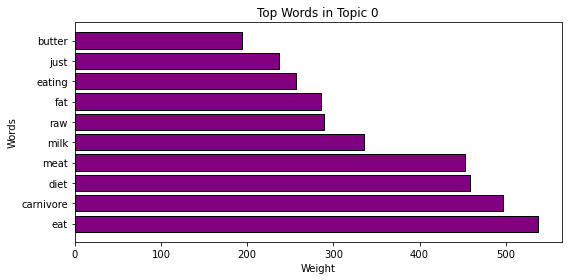

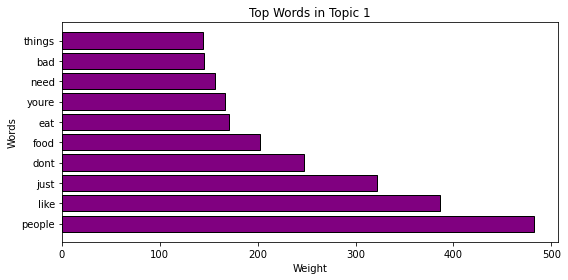

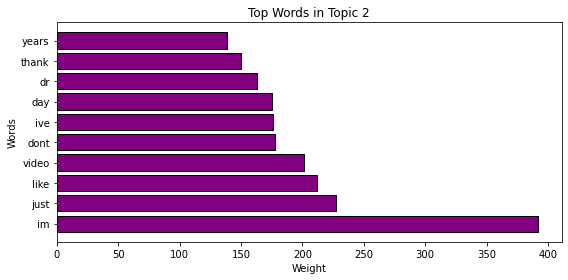

In [49]:
# Get all feature names (words) learned by the CountVectorizer.
# These words are used by the LDA model to build topics.
words = vectorizer.get_feature_names()

# Loop through each topic discovered by the LDA model.
# enumerate() provides:
# - i      → topic number
# - topic  → word importance scores for that topic
for i, topic in enumerate(lda.components_):

    # Sort word indexes based on their importance scores
    # and select the 10 most important words for the topic.
    top_indices = topic.argsort()[-10:]
    top_words = [words[j] for j in top_indices]
    top_weights = [topic[j] for j in top_indices]
    
    # reverse for better display
    top_words.reverse()
    top_weights.reverse()
    
    plt.figure(figsize=(8,4))
    plt.barh(top_words, top_weights, color="purple", edgecolor="black")
    
    plt.title(f"Top Words in Topic {i}")
    plt.xlabel("Weight")
    plt.ylabel("Words")
    
    plt.tight_layout()
    plt.show()

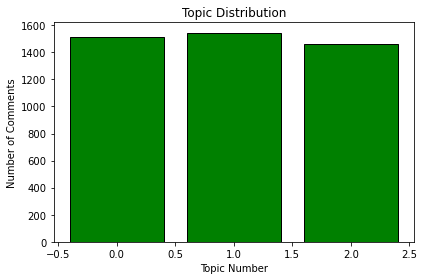

In [50]:
# Transform the document-term matrix using the trained LDA model.
# This calculates the probability distribution of topics for each comment.
# Each row represents a comment,
# and each column represents the probability of belonging to a topic.

topic_distribution = lda.transform(X)

# Identify the dominant topic for each comment.
# argmax() selects the topic with the highest probability score.
topic_counts = np.argmax(topic_distribution, axis=1)

# Count how many comments belong to each dominant topic.
# bincount() calculates the frequency of each topic number.
topic_counts = np.bincount(topic_counts)

plt.figure(figsize=(6,4))
plt.bar(range(len(topic_counts)), topic_counts, color="green", edgecolor="black")

plt.title("Topic Distribution")
plt.xlabel("Topic Number")
plt.ylabel("Number of Comments")

plt.tight_layout()
plt.show()

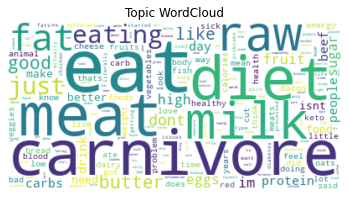

In [51]:
# Create a dictionary containing words and their importance scores.
# lda.components_[0] represents the first topic discovered by the LDA model.
# Higher scores mean the word is more important within that topic.
topic_words = dict([(words[i], lda.components_[0][i]) for i in range(len(words))])

# Create the WordCloud object.
# background_color="white" gives the word cloud a white background.
wc = WordCloud(background_color="white").generate_from_frequencies(topic_words)

# Display the generated word cloud image.
# interpolation="bilinear" smooths the visual appearance.
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Topic WordCloud")
plt.show()

## 4. Network Analysis

In [52]:
# Create a directed graph using NetworkX.
# A directed graph stores relationships where direction matters.
# In this case:
# author  →  person being replied to
G = nx.DiGraph()

# Loop through every row in the dataset.
# Each row represents one comment.
for _, row in df.iterrows():

    # Check whether the comment is a reply to another user.
    # pd.notna() ensures the value is not missing.
    if pd.notna(row["reply_to"]):
        # Add a directed connection between users.
        # This creates an edge from:
        # commenter → user being replied to
        #
        # Example:
        # "User A replied to User B"
        # creates:
        # User A → User B
        G.add_edge(row["author"], row["reply_to"])

# convert to undirected for stable centrality calculations
G_co = G.to_undirected()

### 4.1 Centrality

In [53]:
#  Degree centrality 
# Proportion of users a node interacts with
# High degree = user receives/replies to many comments (high engagement)
degree_cent = nx.degree_centrality(G_co)

In [54]:

# Weighted degree (strength) 
# Since your graph is unweighted, this is same as degree
strength = dict(G_co.degree())

In [55]:
# Betweenness centrality  
# Measures if a user connects different parts of discussion
# Using subgraph to avoid errors and focus on active users
top_nodes = sorted(G_co.degree, key=lambda x: x[1], reverse=True)[:50]
top_nodes = [n[0] for n in top_nodes]

subgraph = G_co.subgraph(top_nodes)

# manual betweenness (stable for your system)
betweenness_cent = dict.fromkeys(subgraph.nodes(), 0.0)

for source in subgraph.nodes():
    paths = nx.single_source_shortest_path(subgraph, source)
    for target, path in paths.items():
        for node in path[1:-1]:
            betweenness_cent[node] += 1

# normalize
n = len(subgraph.nodes())
if n > 2:
    for node in betweenness_cent:
        betweenness_cent[node] /= ((n - 1) * (n - 2))

In [56]:

# Eigenvector centrality 
# High value = connected to influential users
try:
    eigen_cent = nx.eigenvector_centrality(G_co, max_iter=1000)
except:
    print("Eigenvector did not converge, using degree centrality")
    eigen_cent = degree_cent

In [57]:
#  Clustering coefficient 
# Measures how tightly users interact in groups
clustering = nx.clustering(G_co)

In [58]:
# Compile node feature table 
node_features = pd.DataFrame({
    'user_id': list(G_co.nodes()),
    'degree': [G_co.degree(n) for n in G_co.nodes()],
    'degree_centrality': [degree_cent[n] for n in G_co.nodes()],
    'strength': [strength[n] for n in G_co.nodes()],
    'betweenness_centrality': [betweenness_cent.get(n, 0) for n in G_co.nodes()],
    'eigenvector_centrality': [eigen_cent[n] for n in G_co.nodes()],
    'clustering_coefficient': [clustering[n] for n in G_co.nodes()],
})

# preview
print(node_features.head())

                  user_id  degree  degree_centrality  strength  \
0              @BODHI-h6j       2           0.000900         2   
1  @MichaelMartinez-ds1vd       1           0.000450         1   
2              @john_d_91       4           0.001801         4   
3     @MarshEllo189roblox       1           0.000450         1   
4         @SolidState5150       1           0.000450         1   

   betweenness_centrality  eigenvector_centrality  clustering_coefficient  
0                     0.0            1.565559e-20                     0.0  
1                     0.0            3.001976e-15                     0.0  
2                     0.0            6.003953e-15                     0.0  
3                     0.0            1.565559e-20                     0.0  
4                     0.0            1.565559e-20                     0.0  


In [59]:

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 2222
Edges: 1829


In [60]:
# Calculate degree centrality for each user in the graph.
# Degree centrality measures how connected a user is within the network.
#
# A higher score means the user interacts with many others
# or receives many replies from others.
degree_centrality = nx.degree_centrality(G)

# Sort users based on their centrality scores in descending order.
# reverse=True ensures the highest scores appear first.
#
# [:10] selects the top 10 most connected users.
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top users by Degree Centrality:")
for user, score in top_degree:
    print(user, score)

Top users by Degree Centrality:
@DoctorMike 0.02341287708239532
@ashleyhetherington_ 0.01170643854119766
@lirilsoni 0.01170643854119766
@drjayeshsharma 0.00945520036019811
@mephistomadeadeal 0.00810445745159838
@Vegan_Vlogs 0.007654209815398469
@Homesteadhow 0.005402971634398919
@waspwrap1235 0.00405222872579919
@Charlesco 0.00405222872579919
@sogigi 0.00405222872579919


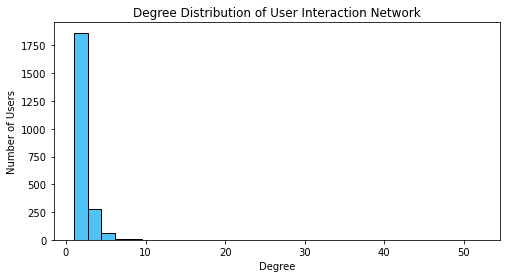

In [61]:
#Visualising the Degree Distribution of the User Interaction Network
degrees = [d for _, d in G.degree()]
plt.figure(figsize=(8,4))
plt.hist(degrees, bins=30, color="#4fc3f7", edgecolor="black")
plt.xlabel("Degree")
plt.ylabel("Number of Users")
plt.title("Degree Distribution of User Interaction Network")
plt.savefig("degree_distribution.png", dpi=150)

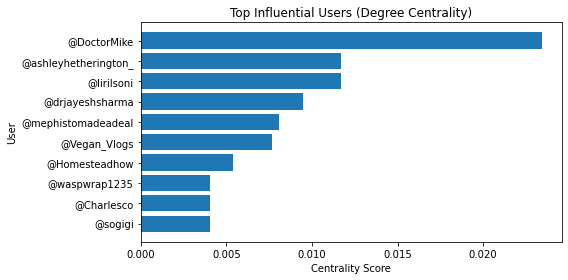

In [62]:
# top 10 users by degree
top_users = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

users = [u for u, _ in top_users]
scores = [s for _, s in top_users]

# reverse for better display
users.reverse()
scores.reverse()

plt.figure(figsize=(8,4))
plt.barh(users, scores)

plt.title("Top Influential Users (Degree Centrality)")
plt.xlabel("Centrality Score")
plt.ylabel("User")

plt.tight_layout()
plt.show()

Total nodes in subgraph: 290
Edges in subgraph: 273


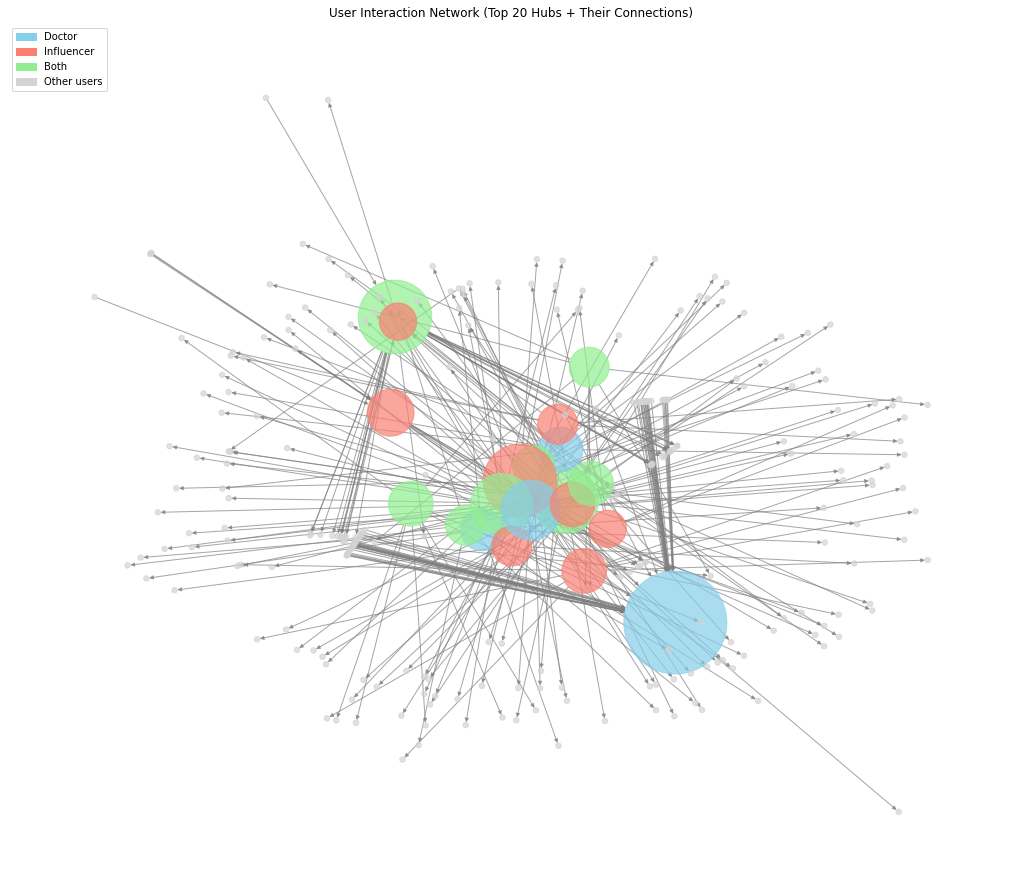

In [63]:
# Remove self-loops
G_clean = G.copy()
G_clean.remove_edges_from(nx.selfloop_edges(G_clean))

# Get top 20 hubs
top_hubs = sorted(G_clean.degree(), key=lambda x: x[1], reverse=True)[:20]
top_hubs = [n for n, _ in top_hubs]

# Also include their neighbours (spokes)
neighbours = set()
for hub in top_hubs:
    neighbours.update(G_clean.predecessors(hub))
    neighbours.update(G_clean.successors(hub))

all_nodes = list(set(top_hubs) | neighbours)
print(f"Total nodes in subgraph: {len(all_nodes)}")

# Convert to real DiGraph
subgraph = nx.DiGraph(G_clean.subgraph(all_nodes))
print(f"Edges in subgraph: {subgraph.number_of_edges()}")

# Colour nodes — hubs larger and coloured, spokes small gray
node_colors = []
node_sizes = []
for n in subgraph.nodes():
    if n in top_hubs:
        label = df[df["author"] == n]["video_label"].mode()
        if len(label) > 0:
            if label[0] == "doctor":
                node_colors.append("skyblue")
            elif label[0] == "influencer":
                node_colors.append("salmon")
            else:
                node_colors.append("lightgreen")
        else:
            node_colors.append("lightgray")
        node_sizes.append(subgraph.degree(n) * 200 + 200)
    else:
        node_colors.append("lightgray")
        node_sizes.append(30)

pos = nx.kamada_kawai_layout(subgraph)

plt.figure(figsize=(14, 12))
nx.draw(
    subgraph, pos,
    node_size=node_sizes,
    node_color=node_colors,
    edge_color="gray",
    alpha=0.7,
    arrows=True,
    arrowsize=8,
    with_labels=False
)

legend = [
    Patch(color="skyblue", label="Doctor"),
    Patch(color="salmon", label="Influencer"),
    Patch(color="lightgreen", label="Both"),
    Patch(color="lightgray", label="Other users")
]
plt.legend(handles=legend, loc="upper left")
plt.title("User Interaction Network (Top 20 Hubs + Their Connections)")
plt.show()

### 4.2 Community Detection

In [64]:
# Community Detection (Louvain) 
# Convert to undirected for Louvain
import community as community_louvain
G_undirected = G.to_undirected()
partition = community_louvain.best_partition(G_undirected)

# Count communities
community_counts = Counter(partition.values())
print(f"\nTotal communities found: {len(community_counts)}")
print("\nCommunity sizes:")
for comm_id, size in sorted(community_counts.items(), key=lambda x: -x[1]):
    print(f"  Community {comm_id}: {size} users")


Total communities found: 687

Community sizes:
  Community 204: 55 users
  Community 124: 53 users
  Community 520: 36 users
  Community 168: 31 users
  Community 505: 31 users
  Community 70: 26 users
  Community 179: 24 users
  Community 174: 23 users
  Community 669: 19 users
  Community 426: 17 users
  Community 20: 16 users
  Community 595: 16 users
  Community 196: 14 users
  Community 497: 14 users
  Community 53: 13 users
  Community 635: 13 users
  Community 142: 12 users
  Community 622: 12 users
  Community 110: 11 users
  Community 678: 11 users
  Community 48: 10 users
  Community 54: 10 users
  Community 467: 10 users
  Community 563: 10 users
  Community 672: 10 users
  Community 200: 9 users
  Community 649: 9 users
  Community 18: 8 users
  Community 19: 8 users
  Community 26: 8 users
  Community 87: 8 users
  Community 120: 8 users
  Community 582: 8 users
  Community 55: 7 users
  Community 98: 7 users
  Community 128: 7 users
  Community 216: 7 users
  Community 2

In [65]:
#  Modularity Score 
# Measures quality of the partition (0 = random, 1 = perfect communities)
modularity = community_louvain.modularity(partition, G_undirected)
print(f"\nModularity Score: {modularity:.4f}")

#  Who are the top users in each community? 
# This is what satisfies the PG interpretation requirement
print("\nTop users per community (by degree):")
for comm_id in sorted(community_counts.keys()):
    # get all users in this community
    members = [node for node, comm in partition.items() if comm == comm_id]
    # rank by degree within the full graph
    top = sorted(members, key=lambda n: G_undirected.degree(n), reverse=True)[:3]
    print(f"  Community {comm_id} ({len(members)} users): {top}")


Modularity Score: 0.9938

Top users per community (by degree):
  Community 0 (1 users): ['@BODHI-h6j']
  Community 1 (3 users): ['@john_d_91', '@MichaelMartinez-ds1vd', '@GuitarCovers124']
  Community 2 (2 users): ['@MarshEllo189roblox', '@SolidState5150']
  Community 3 (2 users): ['@T3alnPurpl3Show', '@lettuce_head4']
  Community 4 (2 users): ['@STAYS_0NLY', '@kimreiling2805']
  Community 5 (1 users): ['@confxetti']
  Community 6 (2 users): ['@CherylKasson', '@meladejesus']
  Community 7 (2 users): ['@Isabobi', '@ab.7272']
  Community 8 (2 users): ['@YAAI_XD', '@user-pw6mk5gf9i']
  Community 9 (3 users): ['@Welcometoworlder', '@ultimate98media', '@logicking3765']
  Community 10 (2 users): ['@Stelbri', '@kintober']
  Community 11 (2 users): ['@SatisfiedBeastYT', '@ChadForquer']
  Community 12 (3 users): ['@SnoopySnoopy0', '@Stadtaxer26', '@RalphJBater']
  Community 13 (2 users): ['@Welcometoworldea', '@philosophyenjoyer']
  Community 14 (2 users): ['@NeptuniaMorgan', '@Lexi_Frids3']
 

In [66]:
#  What label dominates each community? 
# Map user -> video_label from your dataframe
user_label_map = df.groupby("author")["video_label"].agg(
    lambda x: x.value_counts().index[0]  # most common label for that user
).to_dict()

print("\nDominant content type per community:")
for comm_id in sorted(community_counts.keys()):
    members = [node for node, comm in partition.items() if comm == comm_id]
    labels = [user_label_map.get(m, "unknown") for m in members]
    label_counts = Counter(labels)
    dominant = label_counts.most_common(1)[0]
    print(f"  Community {comm_id}: {dominant[0]} ({dominant[1]}/{len(members)} users)")


Dominant content type per community:
  Community 0: doctor (1/1 users)
  Community 1: doctor (3/3 users)
  Community 2: doctor (2/2 users)
  Community 3: doctor (2/2 users)
  Community 4: doctor (2/2 users)
  Community 5: doctor (1/1 users)
  Community 6: doctor (2/2 users)
  Community 7: doctor (2/2 users)
  Community 8: doctor (2/2 users)
  Community 9: doctor (3/3 users)
  Community 10: doctor (2/2 users)
  Community 11: doctor (2/2 users)
  Community 12: doctor (3/3 users)
  Community 13: doctor (2/2 users)
  Community 14: doctor (1/2 users)
  Community 15: doctor (2/2 users)
  Community 16: doctor (3/3 users)
  Community 17: doctor (1/1 users)
  Community 18: doctor (8/8 users)
  Community 19: doctor (6/8 users)
  Community 20: both (15/16 users)
  Community 21: both (4/4 users)
  Community 22: both (2/2 users)
  Community 23: both (2/2 users)
  Community 24: both (2/2 users)
  Community 25: both (2/2 users)
  Community 26: doctor (5/8 users)
  Community 27: doctor (2/2 users)
  

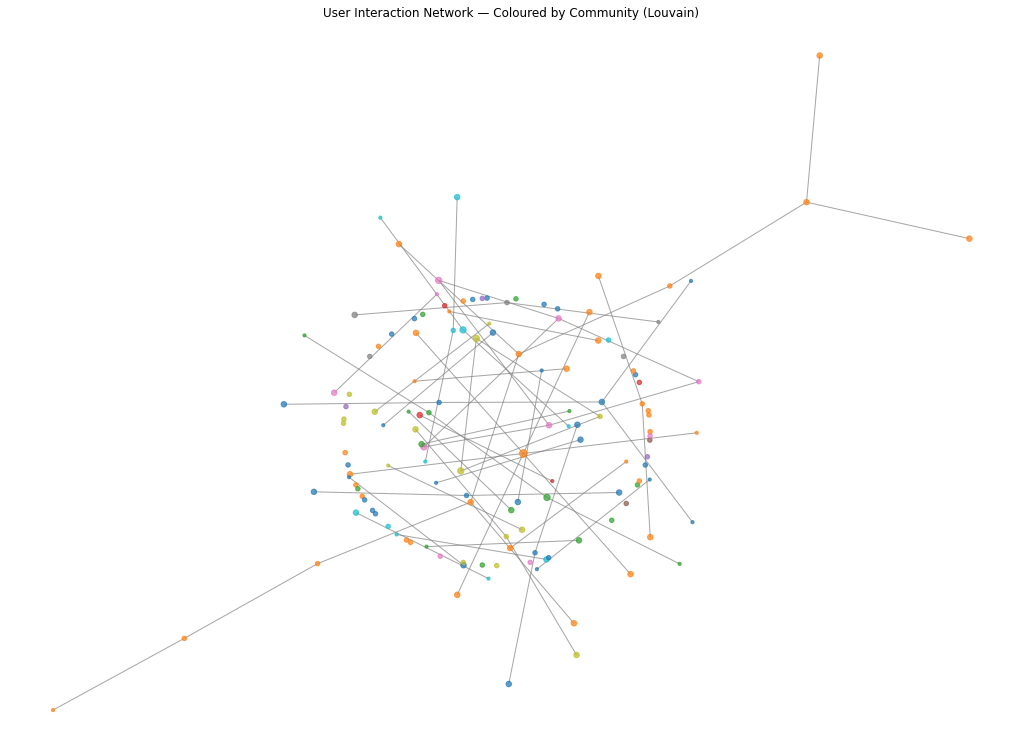

Community detection complete


In [67]:
# ── Visualise Communities ─────────────────────────────────────────────────
# Use top 200 nodes to keep it readable
top_nodes = sorted(G_undirected.degree(), key=lambda x: -x[1])[:200]
top_nodes = [n for n, _ in top_nodes]
subgraph = G_undirected.subgraph(top_nodes)
partition = community_louvain.best_partition(
    G_undirected,
    random_state=42
)
# colour nodes by community
community_colors = [partition.get(node, 0) for node in subgraph.nodes()]
pos = nx.kamada_kawai_layout(subgraph)
node_sizes = [subgraph.degree(n) * 10 for n in subgraph.nodes()]

plt.figure(figsize=(14, 10))
nx.draw(
    subgraph, pos,
    node_color=community_colors,
    cmap=plt.cm.tab10,
    node_size=node_sizes,
    edge_color="gray",
    alpha=0.7,
    with_labels=False
)
plt.title("User Interaction Network — Coloured by Community (Louvain)")
plt.savefig("community_network.png", dpi=150, bbox_inches="tight")
plt.show()
print("Community detection complete")

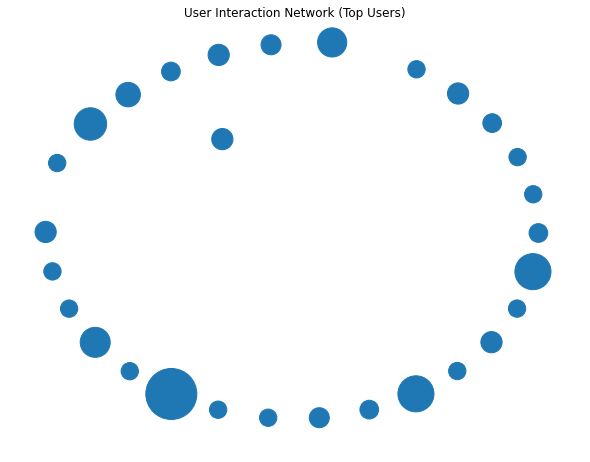

In [68]:
#Visualising the User Interaction Network of the Most Connected Users

# Select the top 30 users with the highest number of connections.
top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:30]
# Extract only the usernames from the degree results.
top_nodes = [n[0] for n in top_nodes]

# Create a smaller subgraph containing only the top connected users.
subgraph = G.subgraph(top_nodes)

# Generate positions for the network visualisation.
# Kamada-Kawai layout helps spread nodes clearly based on their connections.
pos = nx.kamada_kawai_layout(subgraph)

# Set node sizes based on the number of connections each user has.
# More connected users appear larger in the graph.
node_sizes = [G.degree(n) * 50 for n in subgraph.nodes()]

plt.figure(figsize=(8,6))
nx.draw(subgraph, pos, node_size=node_sizes, with_labels=False)

plt.title("User Interaction Network (Top Users)")
plt.show()

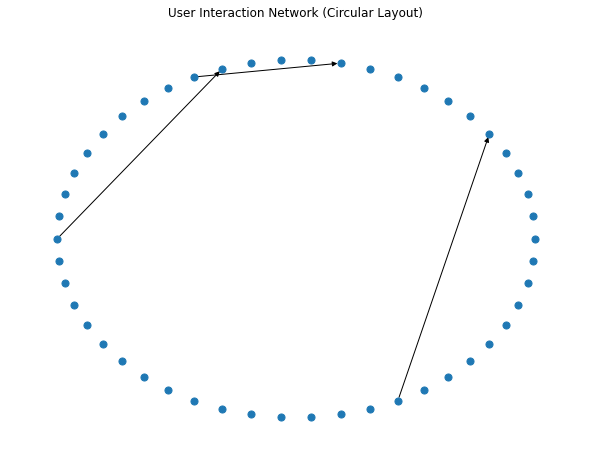

In [69]:
#Visualising the User Interaction Network Using a Circular Layout

# Select the top 50 users with the highest number of connections.
top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:50]

# Extract only the usernames from the degree results.
top_nodes = [n[0] for n in top_nodes]

# Create a smaller subgraph containing only the top connected users.
subgraph = G.subgraph(top_nodes)

# Generate positions for the nodes using a circular layout.
# This arranges all users around a circle for a cleaner visual structure.
pos = nx.circular_layout(subgraph)


plt.figure(figsize=(8,6))
nx.draw(subgraph, pos, node_size=50, with_labels=False)

plt.title("User Interaction Network (Circular Layout)")
plt.show()

## Data Sample Export

In [70]:
# Load the cleaned dataset
df = pd.read_csv("mental_health_cleaned.csv")

print(f"Full dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Get rows WITH reply_to (network edges)
with_replies = df[df['reply_to'].notna()].sample(
    n=min(150, df['reply_to'].notna().sum()), 
    random_state=42
)

# Get rows WITHOUT reply_to (NLP comments)
without_replies = df[df['reply_to'].isna()].sample(
    n=min(350, df['reply_to'].isna().sum()), 
    random_state=42
)

# Combine — 500 rows total
sample = pd.concat([with_replies, without_replies]).sample(
    frac=1, random_state=42
).reset_index(drop=True)

# Save
sample.to_csv("data_sample.csv", index=False)

# Check size
size_mb = os.path.getsize("data_sample.csv") / (1024 * 1024)
print(f"\nSample created!")
print(f"Sample shape: {sample.shape}")
print(f"File size: {size_mb:.2f} MB")
print(f"Under 10 MB: {'YES ' if size_mb < 10 else 'NO ❌'}")
print(f"\nLabel distribution:")
print(sample['video_label'].value_counts())
print(f"\nWith reply_to: {sample['reply_to'].notna().sum()}")
print(f"Without reply_to: {sample['reply_to'].isna().sum()}")

Full dataset shape: (18683, 15)
Columns: ['video_id', 'title', 'channel', 'view_count', 'like_count', 'comment', 'author', 'reply_to', 'comment_likes', 'published_at', 'clean_comment', 'clean_title', 'video_label', 'tokens', 'token_count']

Sample created!
Sample shape: (500, 15)
File size: 0.28 MB
Under 10 MB: YES 

Label distribution:
doctor        288
influencer    111
both          101
Name: video_label, dtype: int64

With reply_to: 150
Without reply_to: 350
